# Olist data EDA

In [1]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
import seaborn as sns
import numpy as np
from plots import Plotter
from scipy.stats import mannwhitneyu, spearmanr, chi2_contingency, kruskal
import os
import sys
sys.path.append('..')

from src.features.haversine import haversine_distance

### DB connection

In [2]:
conn = duckdb.connect('../data/olist.duckdb')

df = conn.execute("SELECT * FROM analytical_base_table").fetchdf()
df.head()

,order_id,customer_unique_id,customer_city,customer_state,order_purchase_timestamp,delivery_days,review_score,review_comment_message,total_price,total_freight_value,product_weight_g,product_category_name,seller_state,total_payment_value,max_installments,customer_lat,customer_lng,seller_lat,seller_lng
0,c31a859e34e3adac22f376954e19b39d,c7b4fb0959a97e7033ff9bef3b1e2ba9,resende,RJ,2018-08-07 23:12:29,6,5,NaN,139.9,59.06,8450,brinquedos,SP,198.96,3,-22.474917,-44.475572,-21.437403,-50.076931
1,9c214ac970e84273583ab523dfafd09b,8c89391790076834500661cc1e5d6860,jacarei,SP,2017-05-08 13:35:48,8,5,NaN,89.9,12.13,1825,casa_conforto,SP,102.03,3,-23.316306,-45.940569,-21.757321,-48.829744
2,f8b6b27efdf0f73f9e9d978fc503c45f,4a4e57e55c5c977bb82ad99a7b6fc190,sao pedro da aldeia,RJ,2018-07-04 16:44:56,7,3,NaN,39.9,19.47,750,cama_mesa_banho,SP,59.37,5,-22.853851,-42.060538,-21.757321,-48.829744
3,93720f5a467d2edd5e84e209e8a9a4f6,9835179d41a3cd33cf230e728fe85798,santos,SP,2018-04-10 22:48:52,8,4,"Uma das peças não encaixava, estava de diâmetr...",79.0,13.46,7225,industria_comercio_e_negocios,SP,92.46,1,-23.969746,-46.321939,-23.493719,-46.546189
4,268762d6a983092f8632e379836806eb,ee87870afcbb29a3c50c068dbd7921a1,campina verde,MG,2017-08-27 13:02:35,10,5,Tudo certo,67.9,28.88,733,relogios_presentes,SC,96.78,3,-19.534302,-49.502095,-26.914469,-49.112263


### Haversine Distancing

In [3]:
df['geo_distance_km'] = haversine_distance(df['customer_lat'], df['customer_lng'], df['seller_lat'], df['seller_lng'])

In [4]:
df.head()

,order_id,customer_unique_id,customer_city,customer_state,order_purchase_timestamp,delivery_days,review_score,review_comment_message,total_price,total_freight_value,product_weight_g,product_category_name,seller_state,total_payment_value,max_installments,customer_lat,customer_lng,seller_lat,seller_lng,geo_distance_km
0,c31a859e34e3adac22f376954e19b39d,c7b4fb0959a97e7033ff9bef3b1e2ba9,resende,RJ,2018-08-07 23:12:29,6,5,NaN,139.9,59.06,8450,brinquedos,SP,198.96,3,-22.474917,-44.475572,-21.437403,-50.076931,589.032280
1,9c214ac970e84273583ab523dfafd09b,8c89391790076834500661cc1e5d6860,jacarei,SP,2017-05-08 13:35:48,8,5,NaN,89.9,12.13,1825,casa_conforto,SP,102.03,3,-23.316306,-45.940569,-21.757321,-48.829744,343.638076
2,f8b6b27efdf0f73f9e9d978fc503c45f,4a4e57e55c5c977bb82ad99a7b6fc190,sao pedro da aldeia,RJ,2018-07-04 16:44:56,7,3,NaN,39.9,19.47,750,cama_mesa_banho,SP,59.37,5,-22.853851,-42.060538,-21.757321,-48.829744,706.899097
3,93720f5a467d2edd5e84e209e8a9a4f6,9835179d41a3cd33cf230e728fe85798,santos,SP,2018-04-10 22:48:52,8,4,"Uma das peças não encaixava, estava de diâmetr...",79.0,13.46,7225,industria_comercio_e_negocios,SP,92.46,1,-23.969746,-46.321939,-23.493719,-46.546189,57.644087
4,268762d6a983092f8632e379836806eb,ee87870afcbb29a3c50c068dbd7921a1,campina verde,MG,2017-08-27 13:02:35,10,5,Tudo certo,67.9,28.88,733,relogios_presentes,SC,96.78,3,-19.534302,-49.502095,-26.914469,-49.112263,821.601356


## Distribution Plots & Statistics

### Delivery Days

In [5]:
len(df[pd.isna(df.delivery_days)])

8

In [6]:
df = df.dropna(subset=['delivery_days'])

In [7]:
delivery_days = df.delivery_days.copy()

print(delivery_days.describe())

count      96773.0
mean     12.503891
std       9.555852
min            0.0
25%            7.0
50%           10.0
75%           16.0
max          210.0
Name: delivery_days, dtype: Float64


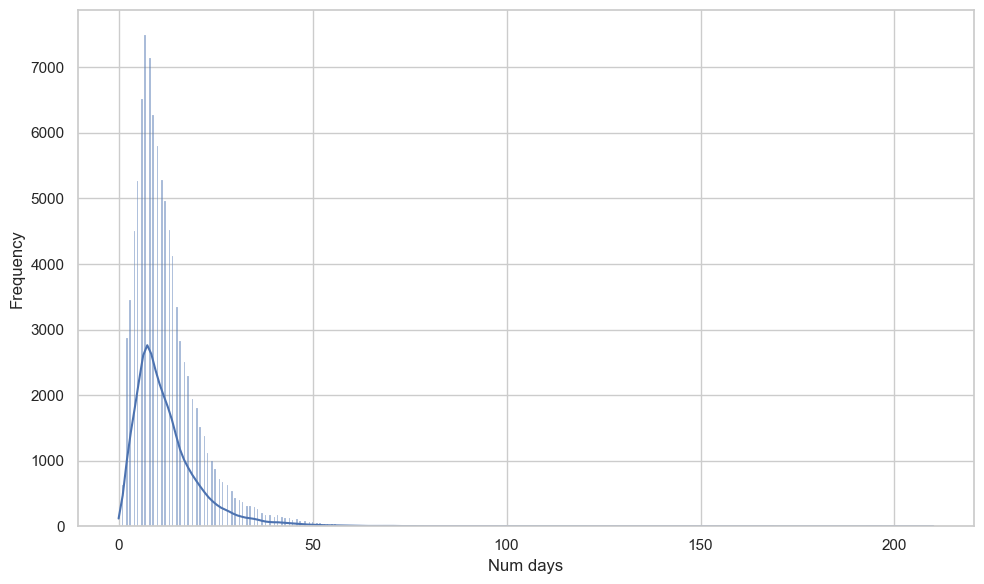

(<Figure size 1000x600 with 1 Axes>,
 <Axes: xlabel='Num days', ylabel='Frequency'>)

In [8]:
delivery_days_list = delivery_days.copy().tolist()

delivery_plot = Plotter()
delivery_plot.histogram(data=delivery_days_list, xlabel="Num days", ylabel="Frequency", show=True)

In [9]:
extream_delay = delivery_days[delivery_days > 100].copy()
high_delay = delivery_days[(delivery_days > 65) & (delivery_days < 100)].copy()

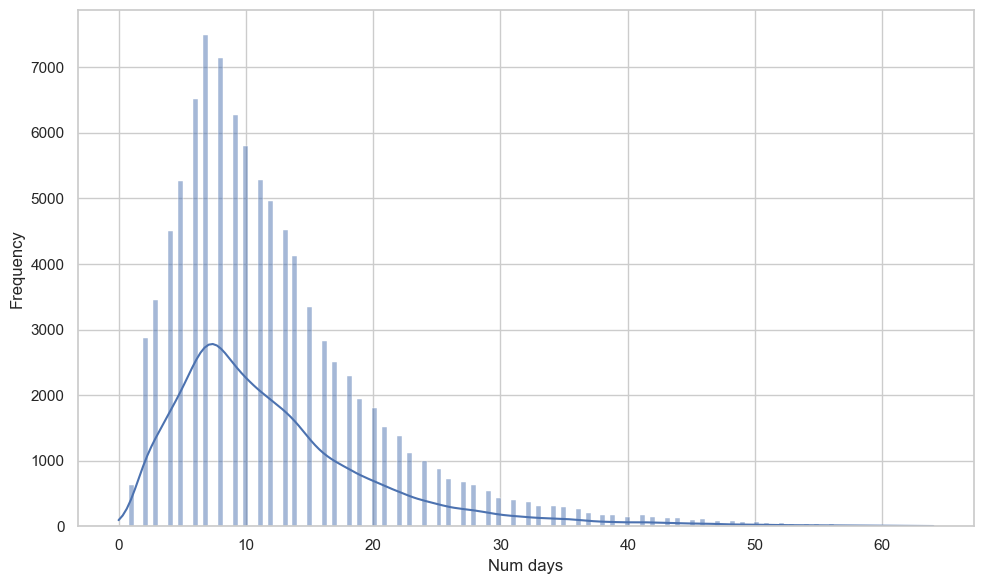

(<Figure size 1000x600 with 1 Axes>,
 <Axes: xlabel='Num days', ylabel='Frequency'>)

In [10]:
filtered_delivery_days_list = delivery_days[delivery_days < 65].copy().tolist()

delivery_plot.histogram(data=filtered_delivery_days_list, xlabel="Num days", ylabel="Frequency")

In [11]:
deliveriy_days_mu = np.mean(delivery_days)
deliveriy_days_std = np.std(delivery_days)
total_deliveries = len(delivery_days)

print(f"Average Delivery Days: {deliveriy_days_mu}")
print(f"Standard Deviation of Delivery Days: {deliveriy_days_std}")

print(f"95% CI: {deliveriy_days_mu - 1.96 * deliveriy_days_std / np.sqrt(total_deliveries), deliveriy_days_mu + 1.96 * deliveriy_days_std / np.sqrt(total_deliveries)}")
print(f"99% CI: {deliveriy_days_mu - 2.58 * deliveriy_days_std / np.sqrt(total_deliveries), deliveriy_days_mu + 2.58 * deliveriy_days_std / np.sqrt(total_deliveries)}")

Average Delivery Days: 12.503890547983426
Standard Deviation of Delivery Days: 9.55580242463165
95% CI: (np.float64(12.443683666774705), np.float64(12.564097429192147))
99% CI: (np.float64(12.424638632922967), np.float64(12.583142463043885))


**INSIGHT**

The 95% CI (12.44, 12.56) is extremely narrow despite the std of 9.56, because our sample size (~97k) gives us a precise estimate of the population mean. This does NOT mean deliveries are consistent — the wide std tells us individual orders are highly unpredictable, which is exactly why a predictive model adds value over simply guessing the mean

Plus we can see the graph is highly skewed to, with most of the deliveris happening between 5 and 15 days. 

In [12]:
p99 = df['delivery_days'].quantile(0.99)
print(f"99th percentile: {p99} days")
print(f"Rows removed: {(df['delivery_days'] > p99).sum()}")

99th percentile: 46.0 days
Rows removed: 918


Orders with delivery_days > 46 (top ~1%) are treated as anomalies and will be excluded from the modelling dataset. This threshold is chosen at the 99th percentile to retain legitimate long-distance deliveries while removing fulfilment failures

### Reviews

In [13]:
reviews = df.review_score.copy()

print(reviews.describe())

count     96127.0
mean     4.154691
std      1.285599
min           1.0
25%           4.0
50%           5.0
75%           5.0
max           5.0
Name: review_score, dtype: Float64


With a mean of 4.15, the data seems to be quite skewed

In [14]:
len(reviews[pd.isna(reviews)])

646

In [15]:
reviews = reviews.dropna()

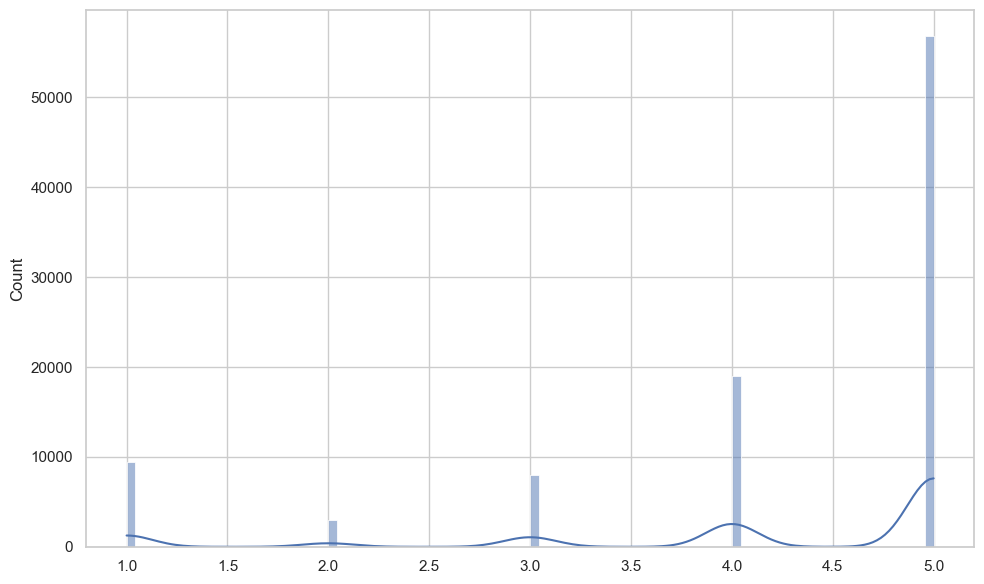

(<Figure size 1000x600 with 1 Axes>, <Axes: ylabel='Count'>)

In [16]:
reviews_s_list = reviews.copy().tolist()

review_plot = Plotter()

review_plot.histogram(reviews_s_list)

**INSIGHT**

The reviews are also very skewed to the positive side of the scale, meaning a normal model without handeling this class imbalance will perform poorly.

In [17]:
## pos_weights for BCELoss

pos_count = (df['review_score'] >= 4).sum()
neg_count = (df['review_score'] <= 3).sum()

## ratio of neg to pos
pos_weight = pos_count / neg_count
print(f"pos_weight: {pos_weight:.3f}")

print("(y=1 = negative review, y=0 = positive review)")

pos_weight: 3.739
(y=1 = negative review, y=0 = positive review)


### Order Purchase dates & timings

In [18]:
deliveries_df = df.copy()[['order_purchase_timestamp', 'delivery_days']]

In [19]:
deliveries_df.head()

,order_purchase_timestamp,delivery_days
0,2018-08-07 23:12:29,6
1,2017-05-08 13:35:48,8
2,2018-07-04 16:44:56,7
3,2018-04-10 22:48:52,8
4,2017-08-27 13:02:35,10


In [20]:
deliveries_df.order_purchase_timestamp = pd.to_datetime(deliveries_df.order_purchase_timestamp)

In [21]:
deliveries_df['day_of_week'] = deliveries_df.order_purchase_timestamp.dt.day_name()
deliveries_df.head()

,order_purchase_timestamp,delivery_days,day_of_week
0,2018-08-07 23:12:29,6,Tuesday
1,2017-05-08 13:35:48,8,Monday
2,2018-07-04 16:44:56,7,Wednesday
3,2018-04-10 22:48:52,8,Tuesday
4,2017-08-27 13:02:35,10,Sunday


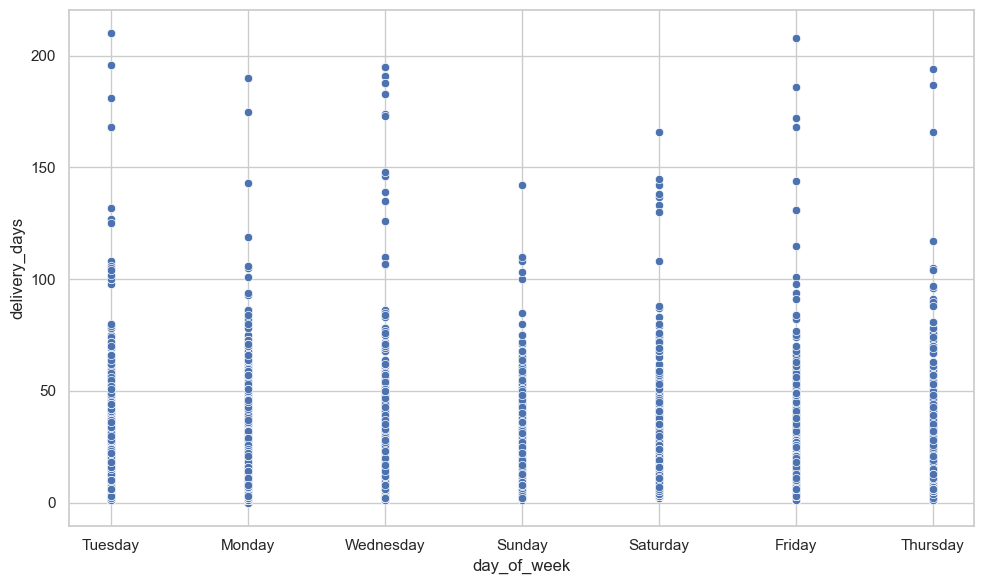

(<Figure size 1000x600 with 1 Axes>,
 <Axes: xlabel='day_of_week', ylabel='delivery_days'>)

In [22]:
dow, dd = deliveries_df.copy()['day_of_week'], deliveries_df.copy().delivery_days
delivery_plot.scatter(x=dow, y=dd)

In [23]:
deliveries_df['hour_of_day'] = deliveries_df.order_purchase_timestamp.dt.hour
deliveries_df.head()

,order_purchase_timestamp,delivery_days,day_of_week,hour_of_day
0,2018-08-07 23:12:29,6,Tuesday,23
1,2017-05-08 13:35:48,8,Monday,13
2,2018-07-04 16:44:56,7,Wednesday,16
3,2018-04-10 22:48:52,8,Tuesday,22
4,2017-08-27 13:02:35,10,Sunday,13


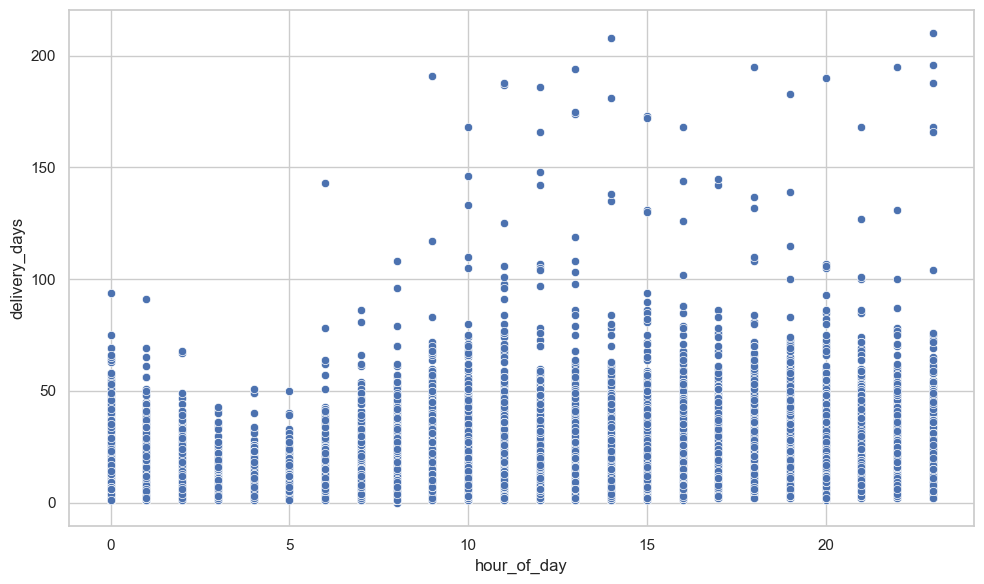

(<Figure size 1000x600 with 1 Axes>,
 <Axes: xlabel='hour_of_day', ylabel='delivery_days'>)

In [24]:
hod, dd = deliveries_df.copy()['hour_of_day'], deliveries_df.copy().delivery_days
delivery_plot.scatter(x=hod, y=dd)

**INSIGHT**

There does not seem to be a significant difference between the deliveries from different days, however, delivery days do seem to have a relation with the hour of the day the order was placed. Specifically orders placed early morning, between 2am and 6am see the most drop in delivery days, while the orders placed at or close to noon see the most increase in delivery days.

### Distances

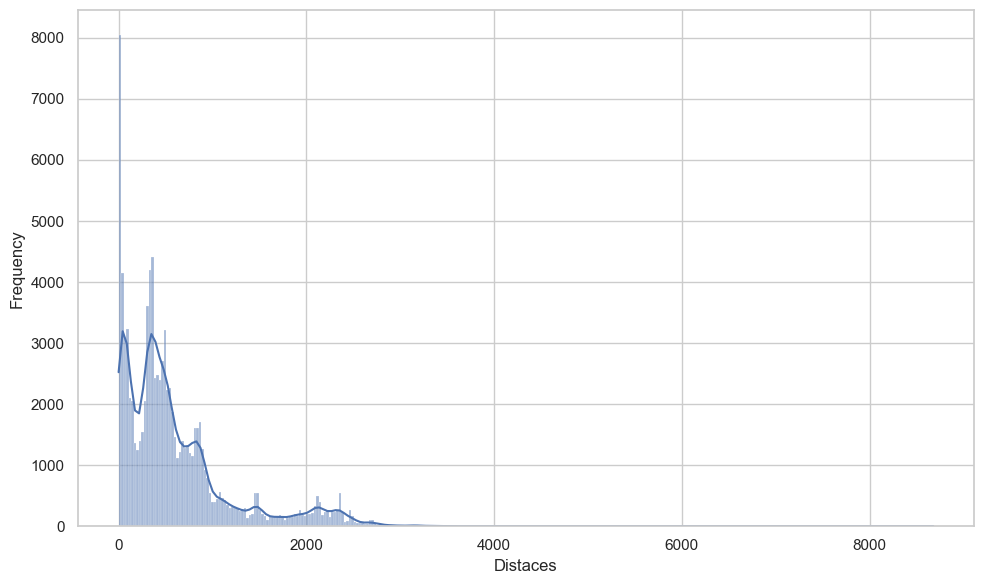

(<Figure size 1000x600 with 1 Axes>,
 <Axes: xlabel='Distaces', ylabel='Frequency'>)

In [25]:
delivery_plot.histogram(df['geo_distance_km'], xlabel="Distaces", ylabel="Frequency")

**INSIGHTS** 

Highest frequence of orders happened from shorter distances

The distribution is heavily right-skewed, which motivates log-transforming geo_distance_km before feeding it to the model to reduce the influence of extreme long-distance outliers

### Correlation Heatmap of all features & targets

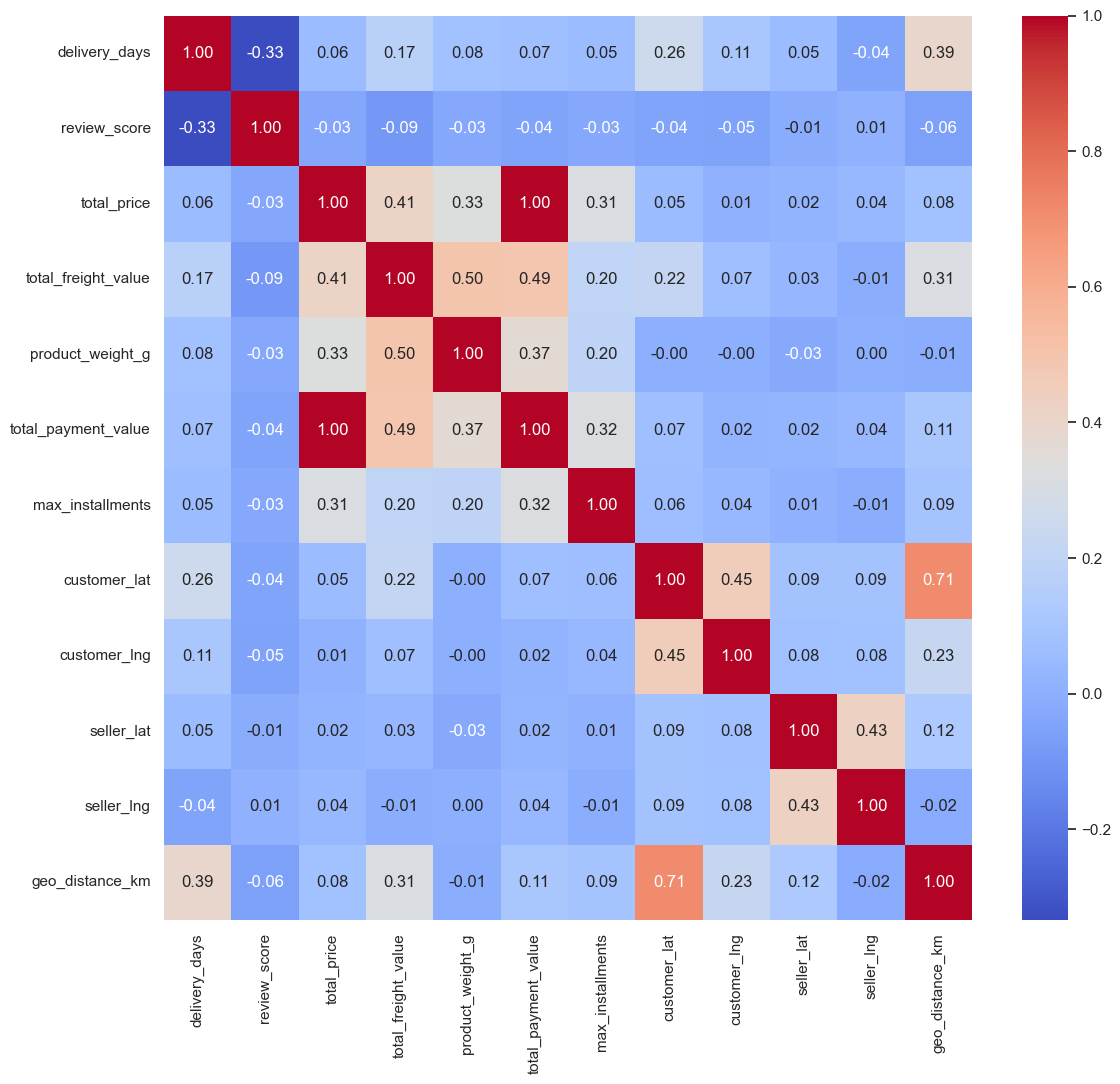

(<Figure size 1200x1100 with 2 Axes>, <Axes: >)

In [26]:
feature_df = df.copy()
heatmap = Plotter()

heatmap.heatmap(data=feature_df)


**INSIGHT**

Something that is worth mentioning here is that the review scores does seem to have a negative correlation with the delivery days.

## Hypothesis Testing

### Mann-Whitney U Test for review scores and delivery days

H0: There is no difference in delivery days between high-rated and low-rated orders.<br/>
H1: Low-rated orders have longer delivery times than high-rated orders.

In [27]:
high_rated_deliveries = df[df['review_score'] >= 4]['delivery_days'].dropna().copy()
low_rated_deliveries = df[df['review_score'] <= 2]['delivery_days'].dropna().copy()

In [28]:
U1, p = mannwhitneyu(high_rated_deliveries, low_rated_deliveries, alternative='less')
n1, n2 = len(high_rated_deliveries), len(low_rated_deliveries)
r = 1 - (2 * U1) / (n1 * n2)  # rank-biserial correlation, effect size
print(f"U={U1:.0f}, p={p:.2e}, effect size r={r:.3f}")

U=287382086, p=0.00e+00, effect size r=0.386


**RESUTLS**

With the P value of 0, the null hypothises is rejected, telling us that there is a difference between the delivery days of high and low ranked orders

Effect size r=0.386 indicates a moderate effect — late deliveries don't just barely differ from on-time ones, the difference is practically meaningful

### Spearman Correlation between Distance and delivery days

H0: There is no correlation between geo_distance_km and delivery_days.<br/>
H1: Greater distance between seller and customer is associated with longer delivery times.

In [29]:
distance = df.dropna(subset=['geo_distance_km', 'delivery_days'])['geo_distance_km'].copy()
deliveriy_days = df.dropna(subset=['geo_distance_km', 'delivery_days'])['delivery_days'].copy()

res = spearmanr(distance, deliveriy_days)
res

SignificanceResult(statistic=np.float64(0.5406271630275318), pvalue=np.float64(0.0))

**RESUTLS**

With a P value of 0, the null hypothesis is rejected. This means that greater distance between seller and customer is associated with longer delivery times.

### Kruskal-Wallis H-test for review scores & freight value

H0: Freight Value does not affect the review score<br/>
H1: There is a relation between freight value and the review score

In [30]:
df_kw = df.dropna(subset=["review_score", "total_freight_value"]).copy()

df_kw['freight_quartile']  = pd.qcut(df_kw["total_freight_value"], q=4, labels=["Q1", "Q2", "Q3", "Q4"])

groups = [
    df_kw[df_kw["freight_quartile"] ==  q]["review_score"].values
    for q in ["Q1", "Q2", "Q3", "Q4"]
]

stat, p = kruskal(*groups)
print(f"Kruskal-Wallis H={stat:.2f}, p={p:.2e}")

# Also print group medians to see the direction
print(df_kw.groupby('freight_quartile')['review_score'].median())


Kruskal-Wallis H=795.08, p=5.05e-172
freight_quartile
Q1    5.0
Q2    5.0
Q3    5.0
Q4    5.0
Name: review_score, dtype: Float64


In [31]:
print(df_kw.groupby('freight_quartile')['review_score'].mean().round(3))
print(df_kw.groupby('freight_quartile')['review_score'].value_counts(normalize=True).unstack())

freight_quartile
Q1    4.314
Q2     4.19
Q3    4.174
Q4     3.94
Name: review_score, dtype: Float64
review_score             1         2         3         4         5
freight_quartile                                                  
Q1                0.066065  0.025211  0.075051  0.195906  0.637767
Q2                0.089104  0.028758  0.084651  0.197977  0.599509
Q3                0.093125  0.028615  0.083143  0.201264  0.593853
Q4                0.142762  0.039802  0.087847  0.193472  0.536117


**RESULTS**

With a P value of 0, we reject the null hypothesis, provideing evidence that freight value affects review scores

### Chi-Squred Test for review scores & late delivery

In [32]:
df_chi = df.dropna(subset=['delivery_days', 'review_score']).copy()
df_chi['is_late'] = df_chi['delivery_days'] > df_chi['delivery_days'].median()
df_chi['is_negative'] = df_chi['review_score'] <= 3

In [33]:
contingency = pd.crosstab(df_chi['is_late'], df_chi['is_negative'])
print(contingency)
print("\nProportions:")
print(contingency.div(contingency.sum(axis=1), axis=0).round(3))

is_negative  False  True 
is_late                  
False        42391   7342
True         33451  12943

Proportions:
is_negative  False  True 
is_late                  
False        0.852  0.148
True         0.721  0.279


In [34]:
chi2, p, dof, _ = chi2_contingency(contingency)
print(f"\nChi2={chi2:.2f}, p={p:.2e}")


Chi2=2486.57, p=0.00e+00


**RESULTS**

From the results of the chi2 test, we can conclude that there is a significant relation between late deliveries and a negative review. <br/>
And seeing from the table the number of negative reviews almost doubled when the order was late

## Time Based Split

In [35]:
df_model = df[df['delivery_days'] <= p99].copy()
df_model = df_model.sort_values('order_purchase_timestamp').reset_index(drop=True)

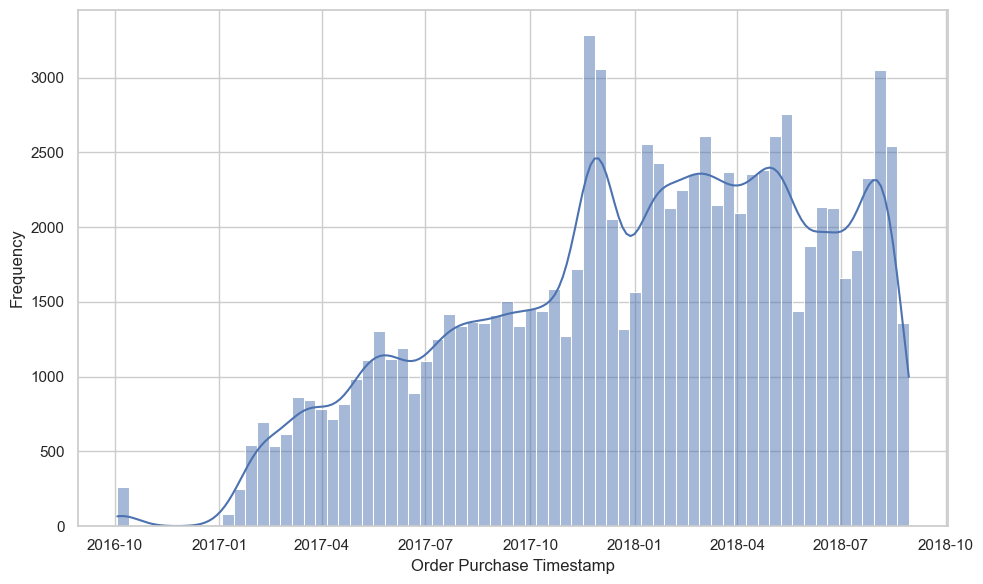

(<Figure size 1000x600 with 1 Axes>,
 <Axes: xlabel='Order Purchase Timestamp', ylabel='Frequency'>)

In [36]:
delivery_plot.histogram(df_model['order_purchase_timestamp'], xlabel='Order Purchase Timestamp', ylabel='Frequency')

There seems to be some missing data from before 2017 so it's better to drop those rows entierly

The peak towards the end of 2017 seems to be the holiday season, followed by the drop to start of 2018, and then a stable period. 

In [37]:
df_model = df_model[df_model['order_purchase_timestamp'] >= '2017-01-01']

n = len(df_model)
train_end = int(n * 0.70)
val_end = int(n * 0.85)

train_df = df_model.iloc[:train_end]
val_df   = df_model.iloc[train_end:val_end]
test_df  = df_model.iloc[val_end:]

In [38]:
print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")
print(f"Train ends:  {train_df['order_purchase_timestamp'].max()}")
print(f"Val ends:    {val_df['order_purchase_timestamp'].max()}")
print(f"Test ends:   {test_df['order_purchase_timestamp'].max()}")

Train: 66916 | Val: 14339 | Test: 14340
Train ends:  2018-04-16 15:06:43
Val ends:    2018-06-21 17:10:24
Test ends:   2018-08-29 15:00:37


In [39]:
os.makedirs("../data/splits", exist_ok=True)

df_model.to_parquet("../data/splits/df_model.parquet", index=False)
train_df.to_parquet("../data/splits/train.parquet", index=False)
val_df.to_parquet("../data/splits/val.parquet", index=False)
test_df.to_parquet("../data/splits/test.parquet", index=False)

### Closing the connection to DuckDB

In [40]:
conn.close()